# TIMMD — 01: Mapa Emocional

Genera una visualización de la intensidad narrativa del partido minuto a minuto. Asigna pesos a cada tipo de evento (tiros, duelos, faltas, etc.) y aplica multiplicadores contextuales según el marcador, el tiempo restante y la dinámica del juego. El resultado es un gráfico que muestra los momentos de mayor tensión del partido, con los goles marcados por equipo y — si hubo — el resultado de la tanda de penales.

## 1. Configuración y carga de datos

Monta Google Drive, carga los eventos y alineaciones del partido desde los archivos Parquet generados por el módulo 00.
El único valor a modificar entre partidos es `MATCH_ID`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

# Si no tenés acceso: abrí este link y elegí 'Agregar acceso directo a Mi unidad' con el nombre TIMMD
# https://drive.google.com/drive/folders/1JCn2VRcg4vnjB5G0cq40gpGMgddG1PQR
DATA_DIR = "/content/drive/MyDrive/TIMMD/data"
MATCH_ID = 3895153                             # ← único valor a cambiar entre partidos

eventos   = pd.read_parquet(f"{DATA_DIR}/eventos_{MATCH_ID}.parquet")
lineup_df = pd.read_parquet(f"{DATA_DIR}/lineups_{MATCH_ID}.parquet")

equipos      = eventos["team"].dropna().unique().tolist()
equipo_local = equipos[0]
equipo_visit = equipos[1]

print(f"✓ Partido {MATCH_ID} cargado — {eventos.shape[0]} eventos")
print(f"  {equipo_local} vs {equipo_visit}")

Mounted at /content/drive
✓ Partido 3895153 cargado — 4520 eventos
  Werder Bremen vs Bayer Leverkusen


## 2. Colores de equipo

Carga el diccionario de colores oficiales por equipo desde el archivo compartido en Drive.
Si un equipo no está en el diccionario, se usa un gris por defecto.

In [3]:
import sys
sys.path.append("/content/drive/MyDrive/TIMMD")
from colores_equipos import get_color

color_local = get_color(equipo_local)
color_visit = get_color(equipo_visit)

print(f"{equipo_local} → {color_local}")
print(f"{equipo_visit} → {color_visit}")

Werder Bremen → #1D9052
Bayer Leverkusen → #E32221


## 3. Función de multiplicador narrativo

Define el multiplicador que pondera la intensidad de cada minuto según contexto: período, tiempo restante, diferencia en el marcador y cambios recientes.
Los momentos de empate, los últimos minutos y las remontadas reciben mayor peso.

In [4]:
def multiplicador_narrativo_v3(row):
    periodo    = row.get("period_mode", 1)
    minuto     = row["minute"]
    diferencia = abs(row["diferencia"])
    cambio     = row["cambio_marcador"]

    base = 1.0 if periodo <= 2 else 1.3

    fin_periodo       = {1: 45, 2: 90, 3: 105, 4: 120}
    minutos_restantes = fin_periodo.get(int(periodo), 90) - minuto
    if minutos_restantes <= 5:
        factor_tiempo = 1.6
    elif minutos_restantes <= 10:
        factor_tiempo = 1.3
    else:
        factor_tiempo = 1.0

    if diferencia == 0:
        factor_marcador = 1.5
    elif diferencia == 1:
        factor_marcador = 1.1
    else:
        factor_marcador = 0.7

    factor_remontada = 1.0 + min(abs(cambio) * 0.35, 0.7)

    factor_arranque = 0.5 if minuto <= 2 else (0.75 if minuto <= 5 else 1.0)

    return min(base * factor_tiempo * factor_marcador * factor_remontada * factor_arranque, 3.5)

## 4. Preparación de datos

Asigna pesos narrativos a cada tipo de evento, reconstruye el marcador minuto a minuto y calcula la intensidad narrativa suavizada.
También extrae los goles del partido y prepara los datos de la tanda de penales si existió.

In [5]:
eventos["tiempo_seg"] = eventos["minute"] * 60 + eventos["second"]

pesos = {
    "Shot": 8, "Goal Keeper": 4, "Duel": 4, "Block": 3,
    "Clearance": 3, "Interception": 3, "Ball Recovery": 2,
    "Foul Committed": 2, "Foul Won": 2, "Dribble": 2,
    "Pressure": 1.5, "Dispossessed": 1, "Miscontrol": 1,
    "Bad Behaviour": 2, "Referee Ball-Drop": 2, "50/50": 2,
    "Pass": 0, "Carry": 0, "Ball Receipt*": 0,
}
eventos["intensidad"] = eventos["type"].map(pesos).fillna(0)

In [6]:
# Reconstruir marcador minuto a minuto
eventos_sorted = eventos.sort_values("tiempo_seg").copy()
marcador       = {equipo_local: 0, equipo_visit: 0}
marcador_historia = []

for _, ev in eventos_sorted.iterrows():
    if ev["type"] == "Shot" and ev.get("shot_outcome") == "Goal" and ev["period"] < 5:
        marcador[ev["team"]] += 1
    marcador_historia.append({
        "index":       ev.name,
        "goles_local": marcador[equipo_local],
        "goles_visit": marcador[equipo_visit],
        "diferencia":  marcador[equipo_local] - marcador[equipo_visit],
    })

marcador_df   = pd.DataFrame(marcador_historia).set_index("index")
eventos_sorted = eventos_sorted.join(marcador_df)

In [7]:
# Calcular cambio de marcador en ventana de 10 minutos
por_minuto = (
    eventos_sorted[eventos_sorted["period"] < 5]
    .groupby("minute")
    .agg(diferencia=("diferencia", "last"), intensidad=("intensidad", "sum"))
    .reset_index()
)
por_minuto["diferencia_previa"] = por_minuto["diferencia"].shift(10).fillna(por_minuto["diferencia"])
por_minuto["cambio_marcador"]   = por_minuto["diferencia"] - por_minuto["diferencia_previa"]

In [8]:
# Calcular intensidad narrativa con multiplicadores y suavizado
for col in ['period_mode', 'period_mode_x', 'period_mode_y']:
    if col in por_minuto.columns:
        por_minuto = por_minuto.drop(columns=[col])

periodo_por_minuto = (
    eventos_sorted[eventos_sorted["period"] < 5]
    .groupby("minute")["period"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={"period": "period_mode"})
)
por_minuto = por_minuto.merge(periodo_por_minuto, on="minute", how="left")
por_minuto["period_mode"] = por_minuto["period_mode"].fillna(1).astype(int)

conflicto_por_minuto = (
    eventos_sorted[
        (eventos_sorted["period"] < 5) &
        (eventos_sorted["type"].isin(["Bad Behaviour", "Foul Committed", "Foul Won", "Referee Ball-Drop", "Duel"]))
    ]
    .groupby("minute").size().reset_index(name="n_conflicto")
)
por_minuto = por_minuto.merge(conflicto_por_minuto, on="minute", how="left")
por_minuto["n_conflicto"]   = por_minuto["n_conflicto"].fillna(0)
por_minuto["factor_cluster"] = por_minuto["n_conflicto"].apply(
    lambda n: 1.0 + min((n - 2) * 0.25, 1.2) if n >= 3 else 1.0)

por_minuto["multiplicador"]        = por_minuto.apply(multiplicador_narrativo_v3, axis=1)
por_minuto["multiplicador"]        = (por_minuto["multiplicador"] * por_minuto["factor_cluster"]).clip(upper=3.5)
por_minuto["intensidad_narrativa"] = por_minuto["intensidad"] * por_minuto["multiplicador"]
por_minuto["intensidad_narrativa"] = por_minuto.apply(
    lambda row: max(row["intensidad_narrativa"], row["n_conflicto"] * 4)
    if row["n_conflicto"] >= 3 else row["intensidad_narrativa"], axis=1)
por_minuto["intensidad_suavizada"] = (
    por_minuto["intensidad_narrativa"].rolling(window=5, center=True, min_periods=1).mean())

In [9]:
# Extraer goles y mapear nombres de display
goles = eventos[
    (eventos["type"] == "Shot") & (eventos["shot_outcome"] == "Goal")
][["minute", "team", "player"]].copy()

nombre_map      = dict(zip(lineup_df["player_name"], lineup_df["nombre_display"]))
goles["apellido"] = goles["player"].map(nombre_map).fillna(goles["player"])

In [10]:
# Preparar datos de tanda de penales (si existió)
penalties_events = eventos[(eventos["period"] >= 5) & (eventos["type"] == "Shot")].copy()

penales_por_equipo = {}
for team_name in penalties_events["team"].unique():
    penales_por_equipo[team_name] = (
        penalties_events[penalties_events["team"] == team_name]
        .sort_values("timestamp")["shot_outcome"].tolist()
    )

goles_pen = {team: outcomes.count("Goal") for team, outcomes in penales_por_equipo.items()}
int_local = eventos[eventos["team"] == equipo_local]["intensidad"].sum()
int_visit = eventos[eventos["team"] == equipo_visit]["intensidad"].sum()

goles_local = marcador[equipo_local]
goles_visit = marcador[equipo_visit]
total_goles = max(goles_local + goles_visit, 1)
total_int   = int_local + int_visit

score_local = 0.7 * int_local + 0.3 * (goles_local / total_goles) * total_int
score_visit = 0.7 * int_visit + 0.3 * (goles_visit / total_goles) * total_int

dominante = equipo_local if score_local >= score_visit else equipo_visit

## 5. Visualización — Mapa Emocional

Grafica la intensidad narrativa suavizada a lo largo del partido con los goles de cada equipo marcados como líneas verticales.
Si el partido tuvo tanda de penales, se agrega un panel lateral con los resultados de cada cobro.

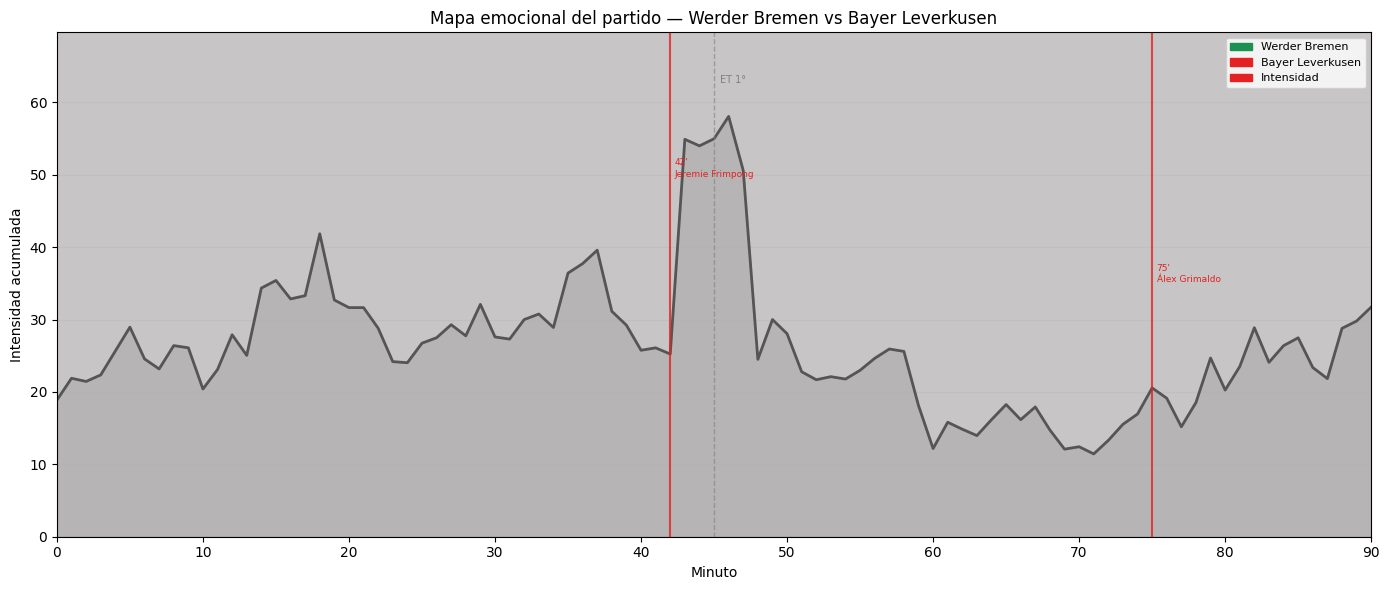

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

max_periodo = eventos[eventos["period"] < 5]["period"].max()
hay_penales = 5 in eventos["period"].values
minuto_max  = por_minuto["minute"].max()
x_limite    = min(minuto_max + 2, {1: 45, 2: 90, 3: 105, 4: 120}.get(max_periodo, 90))

cortes_posibles = {45: "ET 1°", 90: "ET 2°", 105: "Prórroga 1°", 120: "Prórroga 2°"}
cortes = {m: l for m, l in cortes_posibles.items() if m < x_limite}

if hay_penales:
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1])
    ax     = fig.add_subplot(gs[0])
    ax_pen = fig.add_subplot(gs[1])
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax_pen  = None

# Assign specific colors for Barcelona and Sevilla if get_color returns default grey
plot_color_local = color_local
plot_color_visit = color_visit
if color_local == '#CCCCCC' and equipo_local == 'Barcelona':
    plot_color_local = '#A50044' # Example Barcelona color
if color_visit == '#CCCCCC' and equipo_visit == 'Sevilla':
    plot_color_visit = '#E9B622' # Example Sevilla color

colores_equipos = {equipo_local: plot_color_local, equipo_visit: plot_color_visit}

# Si los colores son muy similares, forzar contraste
def colores_son_similares(c1, c2, umbral=80):
    r1,g1,b1 = int(c1[1:3],16), int(c1[3:5],16), int(c1[5:7],16)
    r2,g2,b2 = int(c2[1:3],16), int(c2[3:5],16), int(c2[5:7],16)
    return abs(r1-r2) + abs(g1-g2) + abs(b1-b2) < umbral

if colores_son_similares(plot_color_local, plot_color_visit):
    plot_color_visit = "#444444"
    colores_equipos = {equipo_local: plot_color_local, equipo_visit: plot_color_visit}

datos_plot = por_minuto[por_minuto["minute"] <= x_limite]
ax.plot(datos_plot["minute"], datos_plot["intensidad_suavizada"], color="#555555", linewidth=2)
ax.fill_between(datos_plot["minute"], datos_plot["intensidad_suavizada"], alpha=0.15, color="#555555")

y_max = datos_plot["intensidad_suavizada"].max()

for minuto, label in cortes.items():
    ax.axvline(x=minuto, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(minuto + 0.4, y_max * 1.08, label, fontsize=7, color="gray")

niveles         = [0.90, 0.65, 0.42]
goles_regulares = goles[goles["minute"] <= x_limite]

for i, (_, gol) in enumerate(goles_regulares.iterrows()):
    color  = colores_equipos[gol["team"]]
    nombre = gol["apellido"]
    nivel  = niveles[i % len(niveles)]
    ax.axvline(x=gol["minute"], color=color, linewidth=1.5, alpha=0.8)
    ax.text(gol["minute"] + 0.3, y_max * nivel,
            f"{gol['minute']}'\n{nombre}", fontsize=6.5, color=color, va="top", linespacing=1.3)

patches = [mpatches.Patch(color=c, label=e) for e, c in colores_equipos.items()]
patches.append(mpatches.Patch(color=colores_equipos[dominante], label="Intensidad"))
ax.legend(handles=patches, fontsize=8, loc="upper right")
ax.set_xlim(0, x_limite)
ax.set_ylim(0, y_max * 1.2)
ax.set_xlabel("Minuto")
ax.set_ylabel("Intensidad acumulada")
ax.set_title(f"Mapa emocional del partido — {equipo_local} vs {equipo_visit}")
ax.grid(axis="y", alpha=0.3)
ax.set_facecolor('#c7c5c5')

if hay_penales and ax_pen is not None:
    ax_pen.set_aspect("equal")
    ax_pen.axis("off")
    ax_pen.set_xlim(0, 10)
    ax_pen.set_ylim(0, 10)
    ax_pen.text(5, 9.5, "Penales", ha="center", va="top", fontsize=10, fontweight="bold")

    y_posiciones = [7.5, 3.5]
    radio        = 0.45
    espaciado    = 1.15

    for idx, eq in enumerate(colores_equipos.keys()):
        color    = colores_equipos[eq]
        outcomes = penales_por_equipo.get(eq, [])
        n_goles  = goles_pen.get(eq, 0)
        y        = y_posiciones[idx]

        ax_pen.text(5, y + 1.2, f"{eq}  {n_goles}",
                    ha="center", va="center", fontsize=8, color=color, fontweight="bold")

        n       = len(outcomes)
        x_start = 5 - (n - 1) * espaciado / 2
        for j, outcome in enumerate(outcomes):
            cx   = x_start + j * espaciado
            cy   = y
            circ = plt.Circle((cx, cy), radio, color=color,
                               fill=(outcome == "Goal"), linewidth=1.8, zorder=3)
            ax_pen.add_patch(circ)
            if outcome != "Goal":
                ax_pen.text(cx, cy, "✕", ha="center", va="center", fontsize=9, color=color)

plt.tight_layout()
plt.show()


## 6. Resumen ejecutivo

Genera un resumen automático del partido: clasificación por intensidad, resultado final, minuto pico, equipo dominante y los 5 momentos más intensos.
La interpretación narrativa se asigna automáticamente según el nivel de intensidad máxima alcanzada.

In [ ]:
idx_max             = por_minuto["intensidad_suavizada"].idxmax()
minuto_pico         = por_minuto.loc[idx_max, "minute"]
intensidad_maxima   = por_minuto.loc[idx_max, "intensidad_suavizada"]
intensidad_promedio = por_minuto["intensidad_suavizada"].mean()
top_5               = por_minuto.nlargest(5, "intensidad_suavizada")



if intensidad_maxima >= 35:
    clasificacion = "PARTIDO ÉPICO 🔥"
elif intensidad_maxima >= 20:
    clasificacion = "PARTIDO MUY INTENSO ⚡"
elif intensidad_maxima >= 10:
    clasificacion = "PARTIDO COMPETITIVO ⚽"
else:
    clasificacion = "PARTIDO TRANQUILO 🧊"

print("═" * 60)
print("  RESUMEN EJECUTIVO")
print("═" * 60)
print(f"Clasificación  : {clasificacion}")
print(f"  Resultado      : {equipo_local} {marcador[equipo_local]} - {marcador[equipo_visit]} {equipo_visit}")
print(f"  Equipo dominante: {dominante}")
print()

print(f"Pico emocional : minuto {int(minuto_pico)}' — intensidad {intensidad_maxima:.1f}")
print(f"  Intensidad media: {intensidad_promedio:.1f}")
print()

print("Top 5 momentos más intensos:")
for _, row in top_5.iterrows():
    print(f"    • Minuto {int(row['minute'])}'  →  {row['intensidad_suavizada']:.1f}")
print()

print("Eventos más frecuentes:")
for evento, cantidad in eventos["type"].value_counts().head(5).items():
    print(f"    • {evento}: {cantidad}")
print()

print(" Interpretación:")
if intensidad_maxima >= 35:
    print("    Partido con múltiples explosiones emocionales y altísima tensión competitiva.")
elif intensidad_maxima >= 20:
    print("    Encuentro con cambios de ritmo constantes y momentos de alta intensidad.")
else:
    print("    Partido de dinámica estable sin grandes picos emocionales.")
print("═" * 60)
print(por_minuto[por_minuto["minute"] <= 5][["minute", "intensidad", "multiplicador", "intensidad_narrativa", "intensidad_suavizada"]])